### Data Processing

###### Task 1:Read in the provided ACW Data using the CSV library
###### Steps:
- I will read the contents of the acw_user_data.csv file using csv.DictReader().
- To easily access the data I will store each as a dictionary in the users_data list.
- I will then include exception handling to ensuring the code can report the problem.

In [1]:
import csv

users_data = []

# Read in the provided ACW user data.
try:
    with open('acw_user_data.csv', mode='r') as csvfile:
        reader = csv.DictReader(csvfile)
        for row in reader:
            users_data.append(row)
            
    print("you have successfully read in the ACW user's record")
    print((f"Number of records loaded: {len(users_data)}"))

except FileNotFoundError as not_found:
    print("The file was not found, see error message below")
    print(not_found)
except Exception as err:
    print("An unexpected error occurred, see error message", err)

you have successfully read in the ACW user's record
Number of records loaded: 1000


###### Task 2: Convert all flat structures into nested structures
###### Steps:
- I will start by creating functions to convert values into the correct data types (integers, floats, and booleans). 
- Next I will create separate functions for the Vehicle, Credit Card, and Address information to organise the data into nested structures. 
- I will loop through each row of the data set, rearrange it and convert the values to its appropriate data type.
- Finally I will create a nested dictionary for vehicle, credit card and Address using the functions created in step 2 to get the nested structures.

In [2]:
import json

nested_user_data = []

# Function to convert data type
def convert_to_int(value):
    """ Convert a value to an integer, if conversion fails return 0."""
    try:
        if value is None or str(value).strip() == '':
            return 0
        return int(float(str(value).strip()))
    except ValueError:
        return 0

def convert_to_float(value):
    """ Convert a value to an float, if conversion fails return 0.0."""
    try:
        if value is None or str(value).strip() == '':
            return 0.0
        return float(str(value).strip())
    except (ValueError, TypeError):
        return 0.0

# Function to convert a value to boolean(bool)    
def convert_to_bool(value):
    """ Convert a value to boolean, return true or false"""
    if value is None:
        return False
    if isinstance(value, bool):
        return value
    if isinstance(value, str):
        return value.strip().lower() in ['true', 't', 'yes', 'y', '1']
    return bool(value)

# Function to create a nested vehicle structure
def create_vehicle(row):
    """
    This function will create nested vehicle structure from the flat CSV row.
    Vehicle consists of: make, model, year, and type
    """
    return {
        "make": row.get("Vehicle Make", "").strip(),
        "model": row.get("Vehicle Model", "").strip(),
        "year": convert_to_int(row.get("Vehicle Year")),
        "type": row.get("Vehicle Type", "").strip()
    }

# Function to create a nested credit card structure
def create_creditcard(row):
    """
    This function will create nested credit card structure from the flat CSV row.
    Credit Card consists of: start_date, end_date, number, security_code, and iban
    """
    return {
        "start_date": row.get("Credit Card Start Date", "").strip(),
        "end_date": row.get("Credit Card Expiry Date", "").strip(),
        "number": convert_to_int(row.get("Credit Card Number", "")),
        "security_code": convert_to_int(row.get("Credit Card CVV", "")),
        "IBAN": row.get("Bank IBAN Number", "").strip()
    }

# Function to create a nested address structure (main address, city, and postcode)
def create_address(row):
    """
    This function will create nested address structure from the flat CSV row.
    Address consists of: main_address, city, and postcode
    """
    return {
        "main_address": row.get("Address Street", "").strip(),
        "city": row.get("Address City", "").strip(),
        "postcode": row.get("Address Postcode", "").strip()
    }

# Convert all data in the provided ACW user data (users_data) to its appropriate data type
for row in users_data:
    person_record = {
        "First Name": row.get("First Name", ""),
        "Last Name": row.get("Last Name", ""),
        "Sex": row.get("Sex", ""),
        "Age (in Years)": convert_to_int(row.get("Age (in Years)")),
        "Marital Status": row.get("Marital Status", ""),
        "Dependants": convert_to_int(row.get("Dependants")),
        "Employer Company": row.get("Employer Company", ""),
        "Distance Commuted to Work (in Km)": convert_to_float(row.get("Distance Commuted to Work (in Km)")),
        "Yearly Salary (in Dollars)": convert_to_int(row.get("Yearly Salary (in Dollars)")),
        "Yearly Pension (in Dollars)": convert_to_int(row.get("Yearly Pension (in Dollars)")),
        "Retired": convert_to_bool(row.get("Retired")),
        
        "Vehicle": create_vehicle(row), # use the create_vehicle function to create vehicle nested structure
        "Credit Card": create_creditcard(row), # use the create_creditcard function to create Credit Card nested structure
        "Address": create_address(row), # use the create_address function to create Address nested structure
    
    }
    
    nested_user_data.append(person_record)

print((f"Number of nested structure records: {len(nested_user_data)}"))
first_record = nested_user_data[0]
print(f"First Name: {first_record['First Name']}")
print(f"Vehicle: {first_record['Vehicle']}")
print(json.dumps(first_record))

Number of nested structure records: 1000
First Name: Kieran
Vehicle: {'make': 'Hyundai', 'model': 'Bonneville', 'year': 2009, 'type': 'Pickup'}
{"First Name": "Kieran", "Last Name": "Wilson", "Sex": "Male", "Age (in Years)": 89, "Marital Status": "married or civil partner", "Dependants": 3, "Employer Company": "N/A", "Distance Commuted to Work (in Km)": 0.0, "Yearly Salary (in Dollars)": 72838, "Yearly Pension (in Dollars)": 7257, "Retired": true, "Vehicle": {"make": "Hyundai", "model": "Bonneville", "year": 2009, "type": "Pickup"}, "Credit Card": {"start_date": "08/18", "end_date": "11/27", "number": 676373692463, "security_code": 875, "IBAN": "GB62PQKB71416034141571"}, "Address": {"main_address": "70 Lydia isle", "city": "Lake Conor", "postcode": "S71 7XZ"}}


###### Task 3: Detect and correct errors in the dependants column
###### Steps:
- I will loop through each record in the dataset and check the Dependants column for missing or empty values.
- If an empty value is found, I will record the row number in a separate list.
- After which I will then display the row numbers containing missing data.

In [3]:
empty_dependant_rows = []

# Enumerate through the provided ACW user data (users_data) to get the dependant value
for i, row in enumerate(users_data):
    raw_dependant_data = row.get("Dependants")
    # Check if the dependant value is empty or if it has white space
    if (raw_dependant_data.strip() == "" or str(raw_dependant_data).strip() == '""' or str(raw_dependant_data).strip() == '"'):
        empty_dependant_rows.append(i)
# print the index of row that has missing data
print(f"Problematic rows for dependants: {empty_dependant_rows}")
# print the length of the empty cells in Dependant
print(f"Total number of empty cells in Dependant column is: {len(empty_dependant_rows)}")

Problematic rows for dependants: [21, 109, 179, 205, 270, 272, 274, 358, 460, 468, 579, 636, 679, 725, 822, 865, 917, 931, 983]
Total number of empty cells in Dependant column is: 19


###### Task 4: Write all record to a processed.json
###### Steps:
- I will save the processed nested user data to a JSON file named processed.json.
- The data will then be formatted with indentation to improve readability.
- I will include exception handling to report any errors while writing to the file.

In [4]:
try:
    with open('processed.json', mode = 'w') as jsonfile:
        json.dump(nested_user_data, jsonfile, indent=2)
except Exception as err:
    print(f"An unexpected error occurred while saving the JSON file: {err}")

######  To verify that the JSON file was saved correctly and that no data was lost or changed during the writing process:
- I will open the processed.json file and load its contents back into the program.
- I will then compare the loaded data with the original nested_user_data list.

In [5]:
with open('processed.json', mode='r') as jsonfile:
    # Load the JSON data into a Python object
    processed_file = json.load(jsonfile)
    print(len(processed_file))
    # Check that the loaded data matches the nested user data
    print(processed_file == nested_user_data)

1000
True


###### Task 5:  Create two additional file outputs, retired.json (contain retired customer )and employed.json (contain employed customers)
###### Steps:
- I will loop through the user records and categorise customers into two groups.
- Customers whose Retired field is True will be added to the retired_customer list.
- I will then check customers whose Employer Company field contains a valid employer name.
- I will add the employed customers to employed.json.
- I will include exception handling to report any errors that occur while writing the JSON files.
- I will compare the number of customers in the retired_customer and employed_customer lists.

In [6]:
retired_customer = []
employed_customer = []

# Iterate through each user record and separate customers
for customer in nested_user_data:
    # Get the retired customers based on their retired status
    if customer.get("Retired") is True:
        retired_customer.append(customer)
    # Get employed customers based onthe employer field
    elif (
        customer.get("Employer Company").strip().lower() not in ["", "n/a", "na"]
    ):
        employed_customer.append(customer)
        
# open retired.json file and save the list of retired customer
try:
    with open('retired.json', mode='w') as retired_file:
        json.dump(retired_customer, retired_file, indent=2)
    print(f"Retired Customer: {len(retired_customer)}")
except Exception as err:
    print("An unexpected error occurred while saving retired.json:", err)

# open employed.json file and save the list of employed customer
try:
    with open('employed.json', mode='w') as employed_file:
        json.dump(employed_customer, employed_file, indent=2)
    print(f"Employed Customer: {len(employed_customer)}")
except Exception as err:
    print("An unexpected error occurred while saving employed.json:", err)
# Add the two lengths together to compare it with the processed record.
total_len = len(employed_customer) + len(retired_customer)
print(total_len)

Retired Customer: 246
Employed Customer: 754
1000


###### Task 6: 
###### Steps:
- I will create a function to calculate the duration between credit card start and expiry dates in months.
- The start and expiry dates will then be separated into month and year and then converting into a total number of months.
- I will create a second function to compare the duration against the 10years threshold
- Any customer whose credit card duration exceeds 10 years will be flagged for removal.
- I will loop through each customer record and store all flagged customers in a separate list.
- The total number of flagged customers will be displayed.
- Finally, I will save all flagged customer records into remove_ccard.json using JSON format.
- I will include exception handling to report any errors that may occur while writing to the file.

In [7]:
# Calculate the duration between two credit card
def get_ccard_duration(start_d, end_d):
    """
    Calculate the duration between two credit card
    Returns 0 if date values are missing.
    """
    if not start_d or not end_d:
        return 0
    try:
        # Split the dates into month and year
        start_parts = start_d.strip().split("/")
        end_parts = end_d.strip().split("/")
        
        # Convert the start month and year into integers data type
        start_month = int(start_parts[0])
        start_year = int(start_parts[1])
        
        # Convert the end month and year into integers data type
        end_month = int(end_parts[0])
        end_year = int(end_parts[1])
        
        # Convert both dates into their total number of months
        start_total_months = (start_year * 12) + start_month
        end_total_months = (end_year * 12) + end_month

        # Return the duration between the start and end month
        return end_total_months - start_total_months
    except ValueError:
        # If dates are improperly formatted, return 0
        return 0

def decide_card_flag(row, threshold_years=10):
    """
    Determine if a credit card should be flagged for removal.
    Parameters:
    - row: A dictionary representing a single CSV row
    - threshold_years: The threshold in years
    """
    # Convert the threshold into months
    threshold_months = threshold_years * 12

    # Get the credit card start and expiry dates
    start_date = row.get("Credit Card Start Date", "")
    end_date = row.get("Credit Card Expiry Date", "")
    
    # Calculate the duration of the credit card in months
    ccard_duration_months = get_ccard_duration(start_date, end_date)
    
    # Flag the credit card if it exceed the threshold
    return ccard_duration_months > threshold_months
    
flagged_customers = []

for i, row in enumerate(users_data):
    if decide_card_flag(row):
        flagged_customers.append(nested_user_data[i])
print(len(flagged_customers))

# Save all the flagged customer into remove_ccard.json file
try:
    with open('remove_ccard.json', mode='w') as removed_ccard_file:
        json.dump(flagged_customers, removed_ccard_file, indent=2)
except Exception as err:
    print("An unexpected error occurred while saving remove_ccard.json:", err)

252


###### To will verify that the credit card flagging process worked correctly:
- I will load the remove_ccard.json file
- Comparing the number of saved records with the number of flagged customers.

In [8]:
#Check if the length of the flaged customer equal that in remove_ccard.json
try:
    with open('remove_ccard.json', mode='r') as json_file:
        removed_records = json.load(json_file)
    flagged_count = len(flagged_customers)
    removed_count = len(removed_records)
    print(f"Flagged Customers Count: {flagged_count}")
    print(f"Removed Customer Count: {removed_count}")
    if flagged_count == removed_count:
        print("Record have the same length")
    else:
        print("Length does not match")
except FileNotFoundError as not_found:
    print("The file was not found, see error message below")
    print(not_found)
except Exception as err:
    print("An unexpected error occurred, see error message", err)

Flagged Customers Count: 252
Removed Customer Count: 252
Record have the same length


###### Task 7:  You should create a new data attribute for our customers called “Salary-Commute”. Reading in from processed.json: 
- A. Add, and calculate appropriately, this new attribute. It should represent the Salary that a customer earns, per Km of their commute.
- B. Sort these records by that new metric, in ascending order.
- C. Store the output file out as a JSON format, for a commute.json file.
###### Steps:
- I will create a function to calculate a customer Salary-Commute value using their yearly salary and commute distance.
- I will check if a customer distance travle is 1 Km or less, if it is true i will return their yearly salary. Otherwise, I will calculate the Salary-Commute by dividing the yearly salary by the commute distance.
- I will then create a function to return the Salary-Commute value, which I will use as the sorting key.
- After that I will read the customer records from processed.json file created in task 4
- I will create a copy of the customer record and add the new Salary-Commute attribute to it
- I will store all updated customer records in a new list.
- I will sort the updated customer records in ascending order based on the Salary-Commute attribute.
- I will save the sorted records into commute.json file
- I will include exception handling to report any errors that occur while reading from or writing to the JSON files.

In [9]:
def calculate_salary_commute(person):
    """
    Calculate the Salary-Commute for each customer.
    If the commute distance is 1 km or less
    the customer's salary is returned.
    Else, the calculated Salary-Commute value is return.
    """
    salary = person.get("Yearly Salary (in Dollars)", 0)
    distance = person.get("Distance Commuted to Work (in Km)", 0.0)

    # Check if distance traveled is 1 Km or less
    if distance <= 1.0:
        return salary
    else:
        # Calculate Salary divided by commute distance rounded to 2 decimal places
        return(round(salary / distance,2))

def get_salary_commute(person):
    """
    Return the Salary-Commute value of a customer.
    """
    return person["Salary-Commute"]

# Read in the processed.json
try:
    with open("processed.json", "r") as processed_file:
        processed_data = json.load(processed_file)

except Exception as err:
    print(f"An unexpected error occurred while reading processed.json: {err}")
    processed_data = []

# Create a new list containing the Salary-Commute
commute_data = []
for person in processed_data:
    # Create a copy so the original data is preserved
    person_copy = person.copy()

    # Add the Salary-Commute attribute
    person_copy["Salary-Commute"] = calculate_salary_commute(person_copy)

    # Store the updated customer
    commute_data.append(person_copy)

# Sort customers in ascending order of Salary-Commute
commute_data.sort(key=get_salary_commute)


# Save the sorted data to commute.json
try:
    with open("commute.json", mode="w") as commute_file:
        json.dump(commute_data, commute_file, indent=2)
    print(len(commute_data))
    print(f"First cummute record: {commute_data[0]['Salary-Commute']}")
except Exception as err:
    print("An unexpected error occurred while saving commute.json:", err)

1000
First cummute record: 3088.04


In [10]:
print(json.dumps(commute_data[0], indent=2))

{
  "First Name": "Graeme",
  "Last Name": "Jackson",
  "Sex": "Male",
  "Age (in Years)": 52,
  "Marital Status": "single",
  "Dependants": 2,
  "Employer Company": "Smith, Birch and Burke",
  "Distance Commuted to Work (in Km)": 5.52,
  "Yearly Salary (in Dollars)": 17046,
  "Yearly Pension (in Dollars)": 0,
  "Retired": false,
  "Vehicle": {
    "make": "Chevrolet",
    "model": "Rally Wagon 1500",
    "year": 2011,
    "type": "SUV"
  },
  "Credit Card": {
    "start_date": "06/14",
    "end_date": "04/29",
    "number": 4713424668774153,
    "security_code": 3053,
    "IBAN": "GB09ELJH35362236053720"
  },
  "Address": {
    "main_address": "Studio 9 Reid lights",
    "city": "South Ryan",
    "postcode": "E27 9GY"
  },
  "Salary-Commute": 3088.04
}


### Data Visualisation - Using Pandas and Seaborn

###### With use of Pandas and Seaborn read in the original CSV file provided with the assignment.

In [11]:
import pandas as pd
import seaborn as sns

# Read in the original CSV file using Pandas
try:
    dataframe = pd.read_csv("acw_user_data.csv")
    print("you have successfully load acw_user_data.csv file")
except FileNotFoundError as not_found:
    print("The file was not found, see error message below")
    print(not_found)
except Exception as err:
    print("An unexpected error occurred, see error message", err)

you have successfully load acw_user_data.csv file


In [12]:
dataframe

,Address Street,Address City,Address Postcode,Age (in Years),Distance Commuted to Work (in Km),Employer Company,Credit Card Start Date,Credit Card Expiry Date,Credit Card Number,Credit Card CVV,...,Last Name,Marital Status,Yearly Pension (in Dollars),Retired,Yearly Salary (in Dollars),Sex,Vehicle Make,Vehicle Model,Vehicle Year,Vehicle Type
0,70 Lydia isle,Lake Conor,S71 7XZ,89,0.00,NaN,08/18,11/27,676373692463,875,...,Wilson,married or civil partner,7257,True,72838,Male,Hyundai,Bonneville,2009,Pickup
1,00 Wheeler wells,Chapmanton,L2 7BT,46,13.72,Begum-Williams,08/12,11/26,4529436854129855,583,...,Thomas,married or civil partner,0,False,54016,Male,Nissan,ATS,1996,Coupe
2,Studio 33K Joel walk,Randallborough,ME3N 1GH,22,16.02,Hill-Wright,11/19,07/27,4091726363083888495,422,...,Jones,married or civil partner,0,False,68049,Male,GMC,Achieva,2015,"Convertible, Coupe"
3,Studio 46S Bethany lights,East Reece,E10 9RJ,56,19.35,Green LLC,10/17,04/18,4671332769487632633,669,...,Shaw,married or civil partner,0,False,91337,Male,Scion,F150 SuperCrew Cab,1994,Pickup
4,Flat 3 Christine views,Fletcherstad,WS2 9SN,57,5.94,"Hill, Evans and Harrison",04/19,11/27,2245094149128526,659,...,O'Brien,married or civil partner,0,False,18446,Female,Buick,Outback,2020,SUV
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Studio 6 Heather prairie,North Amelia,E9 0HB,48,18.44,Phillips-Pope,04/19,08/26,3563802099155576,908,...,Clark,married or civil partner,0,False,84645,Male,Saturn,Convertible,2015,Van/Minivan
996,Flat 3 Davies run,Greenshire,E7 4UJ,22,19.61,Hughes LLC,05/12,07/28,3591311819315276,675,...,Jones,married or civil partner,0,False,93314,Female,Toyota,Yukon,2015,Van/Minivan
997,Flat 7 Barber motorway,Burrowsshire,L62 8TA,38,6.66,Bailey Group,01/13,05/29,3584931475767707,679,...,Walker,single,0,False,20940,Female,Ford,S6,2020,Sedan
998,00 Tony forks,Abbiebury,NP4 1JL,45,18.13,Foster-Price,04/19,05/23,4090311300716168,775,...,Thomson,married or civil partner,0,False,82412,Male,Scion,Ram 1500 Quad Cab,2015,Pickup


###### 1.  Obtain the Data Series for Salary, and Age, and calculate the following: 
- A. Mean Salary
- B. Median Age

In [13]:
# Obtain the Data Series for Salary and Age.
salary_series = dataframe["Yearly Salary (in Dollars)"]
age_series = dataframe["Age (in Years)"]

#Calculate mean of the Salary
mean_salary = salary_series.mean()
print(f"Mean Salary: ${mean_salary:,}")
#Calculate median of the Age
median_age = age_series.median()
print(f"Median Age: {median_age} years")

Mean Salary: $57,814.078
Median Age: 54.0 years


###### 2. Perform univariate plots of the following data attributes: 
- A. Age, calculating how many bins would be required for a bin_width of 5
###### Steps:
- I will determine the minimum and maximum customer ages from the dataset.
- I will calculate the number of bins required for the histogram.
- I will create a histogram to visualise the distribution of the Age attribute.
- I will add a title to make the chart easier to interpret.

15


Text(0, 0.5, 'Count')

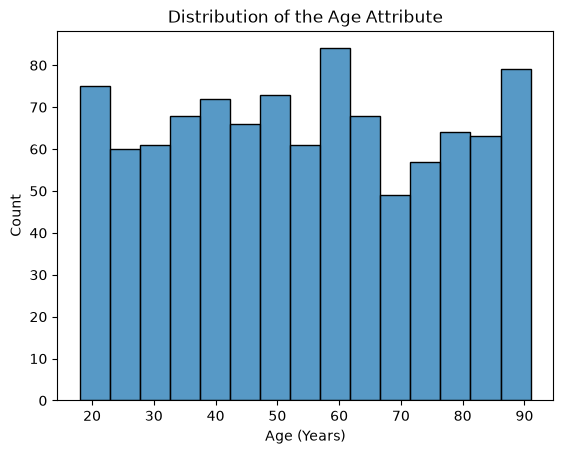

In [14]:

# calculating how many bins would be required for a bin_width of 5
bin_width = 5
age_min = dataframe["Age (in Years)"].min()
age_max = dataframe["Age (in Years)"].max()
bin_num = round((age_max - age_min) /bin_width)
print (bin_num)

# Create histplot to show the distribution of Age attribute
age_plot = sns.histplot(data=dataframe, x = "Age (in Years)", bins = bin_num,)
age_plot.set_title("Distribution of the Age Attribute")
age_plot.set_xlabel("Age (Years)")
age_plot.set_ylabel("Count")

###### B. Dependents, fixing data errors with seaborn itself.

###### Steps:
- I will create a copy of the original dataset to preserve the original data.
- I will use pd.to_numeric() function with errors='coerce' to convert valid values into numbers and convert invalid data into missing values. 
- I will then replace the missing values with 0 and converted it into integers
- I will create a count plot to display the distribution of each number of dependants.
- I will add a title to make the chart easier to interpret.

Text(0.5, 1.0, 'Distribution of the Dependant Attribute')

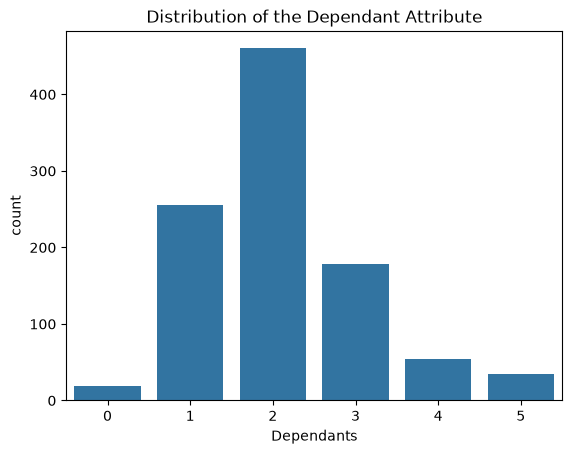

In [15]:
# Create a copy of the original dataset.
clean_dependants = dataframe.copy()
# Convert the Dependants column to numeric values
clean_dependants["Dependants"] = pd.to_numeric(clean_dependants["Dependants"], errors='coerce')
# Replace the empty cell with 0
clean_dependants["Dependants"] = clean_dependants["Dependants"].fillna(0).astype(int)

# Creat a countplot to show the distribution of the dependant attribute
dependant_plot = sns.countplot(data=clean_dependants, x="Dependants")
dependant_plot.set_title("Distribution of the Dependant Attribute")

###### C. Age (of default bins), conditioned on Marital Status

In [16]:
dataframe['Marital Status'].unique()

<StringArray>
['married or civil partner', 'single', 'widowed', 'divorced']
Length: 4, dtype: str

###### Steps:
- I will create a histogram to display the distribution of customer ages.
- I will group the data by Marital Status using different colours.
- I will stack the histogram bars to clearly show the contribution of each marital status.
- I will set a for the y-axis to improve the readability of the chart.
- I will add a title to make the chart easier to interpret.

Text(0.5, 1.0, 'Age Distribution by Marital Status')

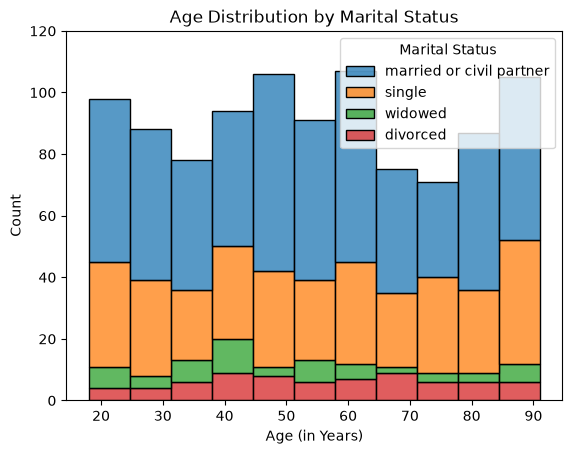

In [17]:
# Create histplot to show the Age Distribution by Marital Status
age_marital_plot = sns.histplot(data = dataframe, x = "Age (in Years)", hue = "Marital Status", multiple = "stack")

# Set the y axis limits
age_marital_plot.set_ylim(0, 120)
# Add titles and labels to the plot
age_marital_plot.set_title("Age Distribution by Marital Status")

######  Perform multivariate plots with the following data attributes:
- A. Commuted distance against salary.
######  Steps:
- I will create a scatter plot to show the relationship between Distance Commuted to Work (in Km) and their yearly Salary (in Dollars).
-  I will add a title to make the chart easier to interpret.

Text(0.5, 1.0, 'Commuted Distance vs Yearly Salary')

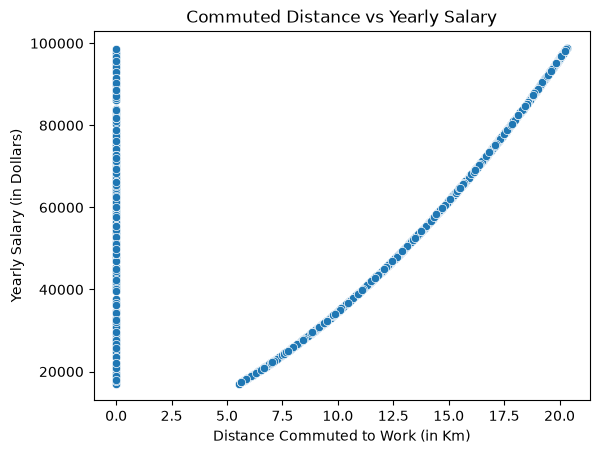

In [18]:
# Create scatterplot to show Commuted distance against salary
distance_salary_plot = sns.scatterplot(data=dataframe, x="Distance Commuted to Work (in Km)", y="Yearly Salary (in Dollars)")
distance_salary_plot.set_title("Commuted Distance vs Yearly Salary")

###### B. Age against Salary
######  Steps:
- I will create a scatter plot to show the relationship between Age (in Years) and their yearly Salary (in Dollars).
- I will add a title to make the chart easier to interpret.

Text(0.5, 1.0, 'Age vs Yearly Salary')

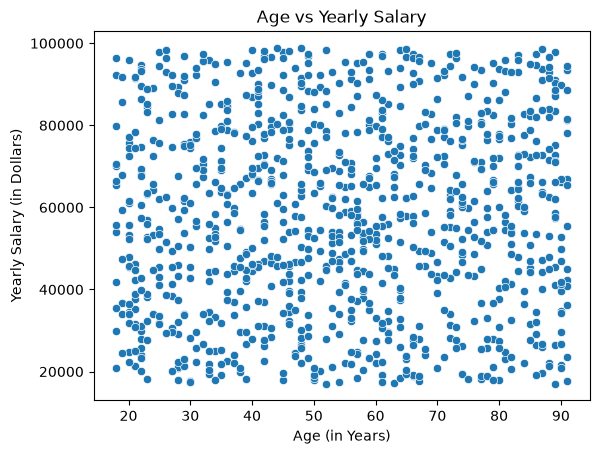

In [19]:
# Create scatterplot to show Age against Salary
age_salary_plot = sns.scatterplot(data=dataframe, x="Age (in Years)", y="Yearly Salary (in Dollars)")
age_salary_plot.set_title("Age vs Yearly Salary")

###### C. Age against Salary conditioned by Dependants
###### Steps:
- I will create a copy of the original dataset to preserve the original data.
- I will use pd.to_numeric() function with errors='coerce' to convert valid values into numbers and convert invalid data into missing values. 
- I will then replace the missing values with 0 and converted it into integers
- I will create a scatter plot to show the relationship between Age and Salary which will be conditioned on Dependant.
- I will choose a palette to make it easier to distinguish different number of Dependants in the scatter plot
- I will add a title to make the chart easier to interpret.

Text(0.5, 1.0, ' Age vs Yearly Salary Conditioned by Dependants')

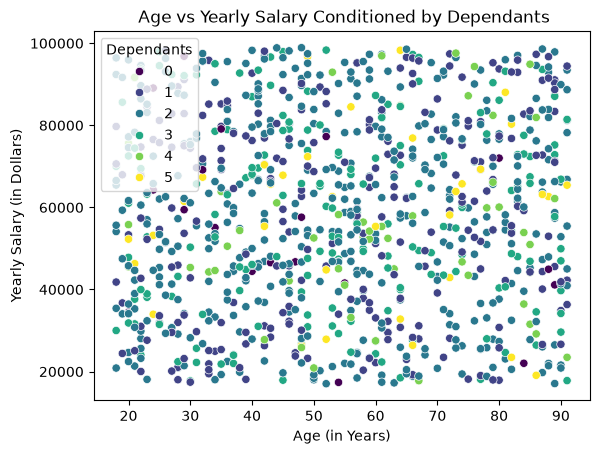

In [20]:
# Create a copy of the original dataset.
dependant_copy = dataframe.copy()
# Convert the Dependants column to numeric values
dependant_copy["Dependants"] = pd.to_numeric(dependant_copy["Dependants"], errors='coerce')
# Replace the empty cell with 0
dependant_copy["Dependants"] = dependant_copy["Dependants"].fillna(0).astype(int)

# Creat a scatterplot to show Age against Salary conditioned by Dependants
age_salary_dep_plot = sns.scatterplot(data=dependant_copy, 
    x="Age (in Years)", 
    y="Yearly Salary (in Dollars)", 
    hue="Dependants",
    palette="viridis"
)
# Add titles to the plot
age_salary_dep_plot.set_title(" Age vs Yearly Salary Conditioned by Dependants")

###### 4. Save the plots which you have produced
###### Steps:
- I will create a dictionary that maps the filename of each plot image to its corresponding plot object.
- I will then iterate through the dictionary.
- For each entry, I will retrieve the associated figure using the get_figure() and save using savefig().

In [21]:
# Create a dictionary
save_plots = {}
# maps the filename of each plot to its corresponding object.
save_plots["./age_plot.png"] = age_plot
save_plots["./dependant_plot.png"] = dependant_plot
save_plots["./age_marital_plot.png"] = age_marital_plot
save_plots["./distance_salary_plot.png"] = distance_salary_plot
save_plots["./age_salary_plot.png"] = age_salary_plot
save_plots["./age_salary_dep_plot.png"] = age_salary_dep_plot
print(save_plots)

{'./age_plot.png': <Axes: title={'center': 'Distribution of the Age Attribute'}, xlabel='Age (Years)', ylabel='Count'>, './dependant_plot.png': <Axes: title={'center': 'Distribution of the Dependant Attribute'}, xlabel='Dependants', ylabel='count'>, './age_marital_plot.png': <Axes: title={'center': 'Age Distribution by Marital Status'}, xlabel='Age (in Years)', ylabel='Count'>, './distance_salary_plot.png': <Axes: title={'center': 'Commuted Distance vs Yearly Salary'}, xlabel='Distance Commuted to Work (in Km)', ylabel='Yearly Salary (in Dollars)'>, './age_salary_plot.png': <Axes: title={'center': 'Age vs Yearly Salary'}, xlabel='Age (in Years)', ylabel='Yearly Salary (in Dollars)'>, './age_salary_dep_plot.png': <Axes: title={'center': ' Age vs Yearly Salary Conditioned by Dependants'}, xlabel='Age (in Years)', ylabel='Yearly Salary (in Dollars)'>}


In [22]:
for filename, graph in save_plots.items():
    graph.get_figure().savefig(filename)